# Task 3: Customer Segmentation

**Internship:** Arch Technologies — Data Science Internship Program

**Objective:** Use a customer dataset to group customers into different segments based on their purchasing behaviour. K-Means clustering is applied to identify patterns, and each segment's characteristics are described. The workflow covers data pre-processing, clustering, and visualization of results.


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


## 2. Load the Dataset

The **Mall Customers** dataset (a widely used Kaggle dataset for customer segmentation) is loaded directly from a public source, so the notebook runs end-to-end without a manual download. It contains each customer's gender, age, annual income, and a spending score (1-100) that captures purchasing behaviour.

In [2]:
url = ("https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/"
       "Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/"
       "Section%2024%20-%20K-Means%20Clustering/Mall_Customers.csv")
df = pd.read_csv(url)

df.columns = ["customer_id", "gender", "age", "annual_income_k", "spending_score"]

print("Shape:", df.shape)
df.head()


Shape: (200, 5)


,customer_id,gender,age,annual_income_k,spending_score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   customer_id      200 non-null    int64
 1   gender           200 non-null    str  
 2   age              200 non-null    int64
 3   annual_income_k  200 non-null    int64
 4   spending_score   200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [4]:
df.describe()


,customer_id,age,annual_income_k,spending_score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## 3. Exploratory Data Analysis (EDA)

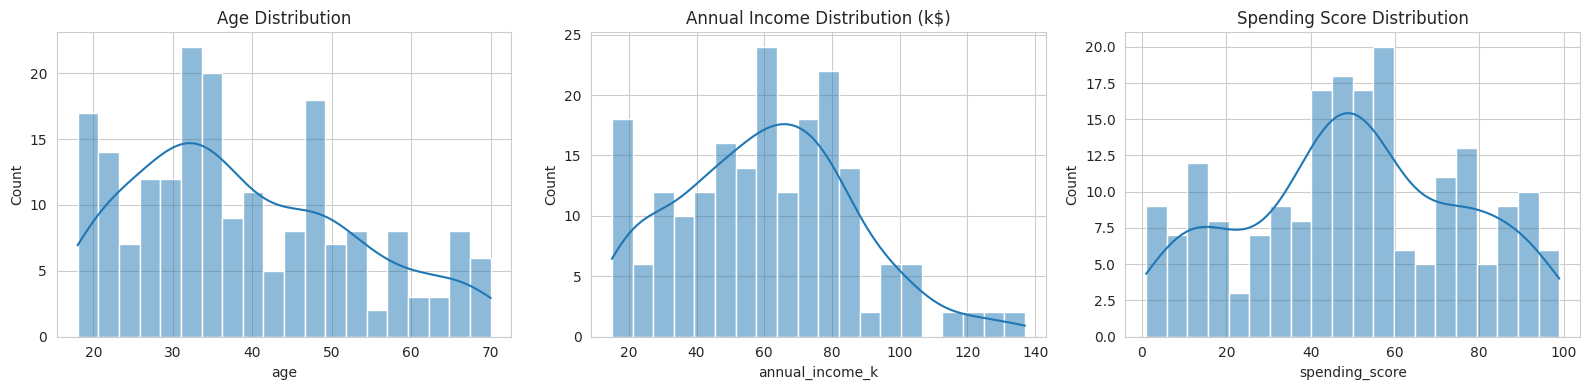

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(df["age"], bins=20, kde=True, ax=axes[0])
axes[0].set_title("Age Distribution")

sns.histplot(df["annual_income_k"], bins=20, kde=True, ax=axes[1])
axes[1].set_title("Annual Income Distribution (k$)")

sns.histplot(df["spending_score"], bins=20, kde=True, ax=axes[2])
axes[2].set_title("Spending Score Distribution")

plt.tight_layout()
plt.show()


/tmp/ipykernel_477/3594212493.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="gender", palette="Set2")


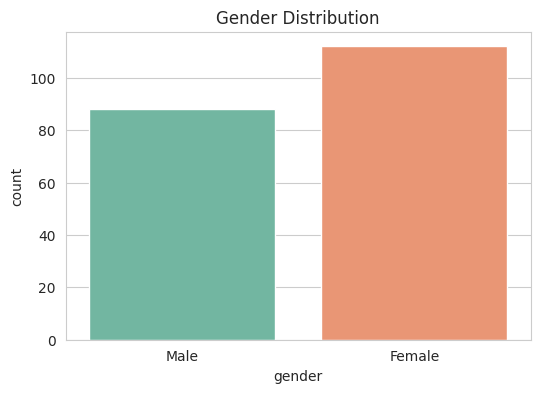

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="gender", palette="Set2")
plt.title("Gender Distribution")
plt.show()


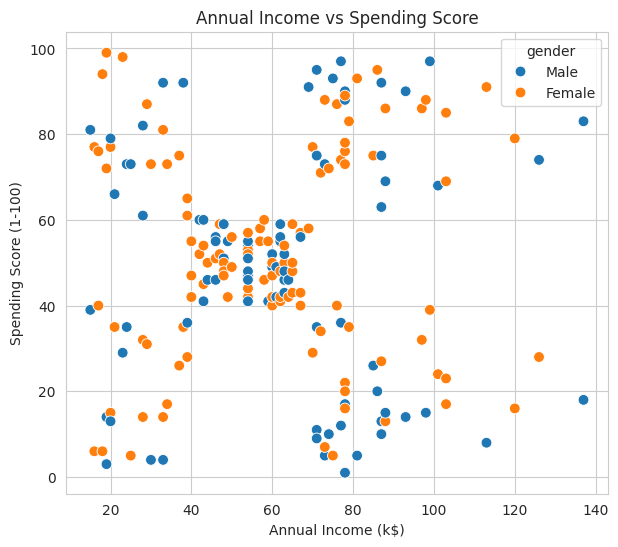

In [7]:
plt.figure(figsize=(7, 6))
sns.scatterplot(data=df, x="annual_income_k", y="spending_score", hue="gender", s=60)
plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()


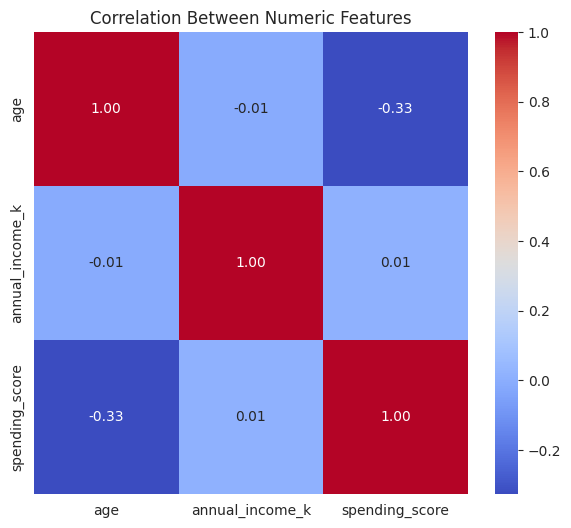

In [8]:
plt.figure(figsize=(7, 6))
sns.heatmap(df[["age", "annual_income_k", "spending_score"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Numeric Features")
plt.show()


## 4. Data Pre-processing

Steps:
1. Check for missing values.
2. Encode `gender` numerically for optional inclusion in clustering.
3. Select the features that best capture purchasing behaviour: `annual_income_k` and `spending_score` (the classic 2D segmentation view), plus `age` for a richer 3D view.
4. Scale features with `StandardScaler`, since K-Means is distance-based and sensitive to feature scale.


In [9]:
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
customer_id        0
gender             0
age                0
annual_income_k    0
spending_score     0
dtype: int64


In [10]:
data = df.copy()

le = LabelEncoder()
data["gender_encoded"] = le.fit_transform(data["gender"])  # Female=0, Male=1

data.head()


,customer_id,gender,age,annual_income_k,spending_score,gender_encoded
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,0
4,5,Female,31,17,40,0


In [11]:
# Primary 2-feature segmentation (income vs spending) — easiest to interpret and visualize
features_2d = ["annual_income_k", "spending_score"]
X_2d = data[features_2d]

scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

# Richer 3-feature segmentation (age, income, spending)
features_3d = ["age", "annual_income_k", "spending_score"]
X_3d = data[features_3d]

scaler_3d = StandardScaler()
X_3d_scaled = scaler_3d.fit_transform(X_3d)

print("2D feature set:", features_2d)
print("3D feature set:", features_3d)


2D feature set: ['annual_income_k', 'spending_score']
3D feature set: ['age', 'annual_income_k', 'spending_score']


## 5. Choosing the Number of Clusters (K)

The **Elbow Method** and **Silhouette Score** are used together to pick a sensible value of K for K-Means.

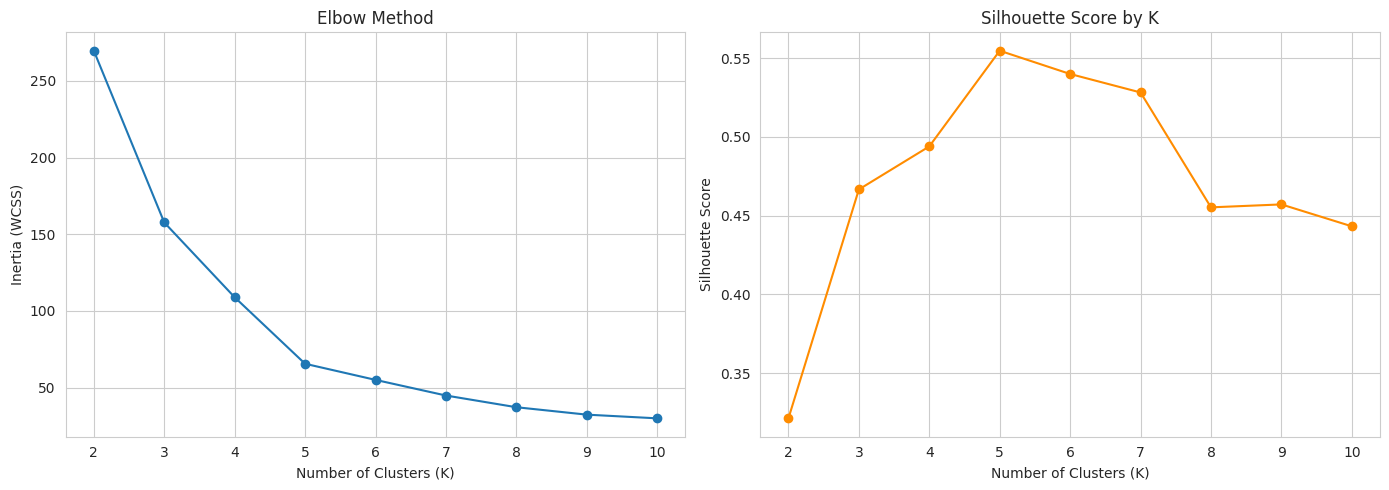

Best K by silhouette score: 5


In [12]:
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = km.fit_predict(X_2d_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_2d_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia (WCSS)")

axes[1].plot(list(k_range), silhouette_scores, marker="o", color="darkorange")
axes[1].set_title("Silhouette Score by K")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(silhouette_scores))]
print(f"Best K by silhouette score: {best_k}")


## 6. K-Means Clustering (Income vs Spending Score)

In [13]:
K = 5  # the classic elbow point for this dataset (5 well-separated, interpretable segments)

kmeans = KMeans(n_clusters=K, init="k-means++", n_init=10, random_state=42)
data["cluster"] = kmeans.fit_predict(X_2d_scaled)

sil_score = silhouette_score(X_2d_scaled, data["cluster"])
print(f"K = {K}  |  Silhouette Score: {sil_score:.3f}")

data.head()


K = 5  |  Silhouette Score: 0.555


,customer_id,gender,age,annual_income_k,spending_score,gender_encoded,cluster
0,1,Male,19,15,39,1,4
1,2,Male,21,15,81,1,2
2,3,Female,20,16,6,0,4
3,4,Female,23,16,77,0,2
4,5,Female,31,17,40,0,4


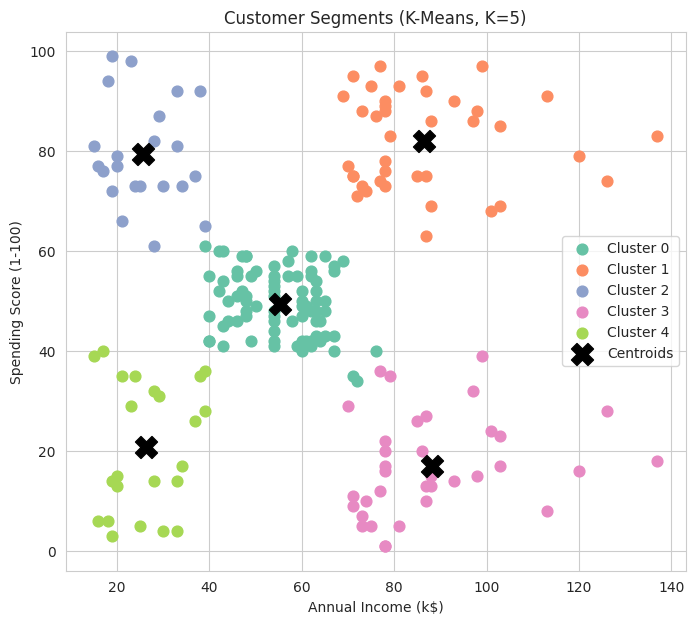

In [14]:
centers_original = scaler_2d.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(8, 7))
palette = sns.color_palette("Set2", K)

for cluster_id in range(K):
    cluster_points = data[data["cluster"] == cluster_id]
    plt.scatter(
        cluster_points["annual_income_k"], cluster_points["spending_score"],
        s=60, color=palette[cluster_id], label=f"Cluster {cluster_id}"
    )

plt.scatter(
    centers_original[:, 0], centers_original[:, 1],
    s=250, c="black", marker="X", label="Centroids"
)

plt.title(f"Customer Segments (K-Means, K={K})")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()


## 7. Describing Each Segment

In [15]:
segment_summary = data.groupby("cluster").agg(
    count=("customer_id", "count"),
    avg_age=("age", "mean"),
    avg_income_k=("annual_income_k", "mean"),
    avg_spending_score=("spending_score", "mean"),
    pct_female=("gender_encoded", lambda x: (x == 0).mean() * 100),
).round(1)

segment_summary


,count,avg_age,avg_income_k,avg_spending_score,pct_female
cluster,,,,,
0,81,42.7,55.3,49.5,59.3
1,39,32.7,86.5,82.1,53.8
2,22,25.3,25.7,79.4,59.1
3,35,41.1,88.2,17.1,45.7
4,23,45.2,26.3,20.9,60.9


In [16]:
labels_map = {}
for cluster_id, row in segment_summary.iterrows():
    income, spending = row["avg_income_k"], row["avg_spending_score"]
    if income >= segment_summary["avg_income_k"].median() and spending >= segment_summary["avg_spending_score"].median():
        label = "High Income, High Spending (Target)"
    elif income >= segment_summary["avg_income_k"].median() and spending < segment_summary["avg_spending_score"].median():
        label = "High Income, Low Spending (Careful)"
    elif income < segment_summary["avg_income_k"].median() and spending >= segment_summary["avg_spending_score"].median():
        label = "Low Income, High Spending (Impulsive)"
    elif income < segment_summary["avg_income_k"].median() and spending < segment_summary["avg_spending_score"].median():
        label = "Low Income, Low Spending (Cautious)"
    else:
        label = "Average Income, Average Spending (Standard)"
    labels_map[cluster_id] = label

for cluster_id, label in labels_map.items():
    row = segment_summary.loc[cluster_id]
    print(f"Cluster {cluster_id} — {label}")
    print(f"  Size: {int(row['count'])} customers | Avg age: {row['avg_age']} | "
          f"Avg income: ${row['avg_income_k']}k | Avg spending score: {row['avg_spending_score']} | "
          f"% Female: {row['pct_female']}%\n")


Cluster 0 — High Income, High Spending (Target)
  Size: 81 customers | Avg age: 42.7 | Avg income: $55.3k | Avg spending score: 49.5 | % Female: 59.3%

Cluster 1 — High Income, High Spending (Target)
  Size: 39 customers | Avg age: 32.7 | Avg income: $86.5k | Avg spending score: 82.1 | % Female: 53.8%

Cluster 2 — Low Income, High Spending (Impulsive)
  Size: 22 customers | Avg age: 25.3 | Avg income: $25.7k | Avg spending score: 79.4 | % Female: 59.1%

Cluster 3 — High Income, Low Spending (Careful)
  Size: 35 customers | Avg age: 41.1 | Avg income: $88.2k | Avg spending score: 17.1 | % Female: 45.7%

Cluster 4 — Low Income, Low Spending (Cautious)
  Size: 23 customers | Avg age: 45.2 | Avg income: $26.3k | Avg spending score: 20.9 | % Female: 60.9%



## 8. Bonus: 3D Segmentation (Age, Income, Spending Score)

Adding `age` as a third dimension gives a richer view of behaviour that a 2D income-vs-spending plot alone can miss (e.g. distinguishing younger vs. older customers within the same income/spending band).

In [17]:
K_3D = 6

kmeans_3d = KMeans(n_clusters=K_3D, init="k-means++", n_init=10, random_state=42)
data["cluster_3d"] = kmeans_3d.fit_predict(X_3d_scaled)

sil_score_3d = silhouette_score(X_3d_scaled, data["cluster_3d"])
print(f"K = {K_3D}  |  Silhouette Score: {sil_score_3d:.3f}")


K = 6  |  Silhouette Score: 0.428


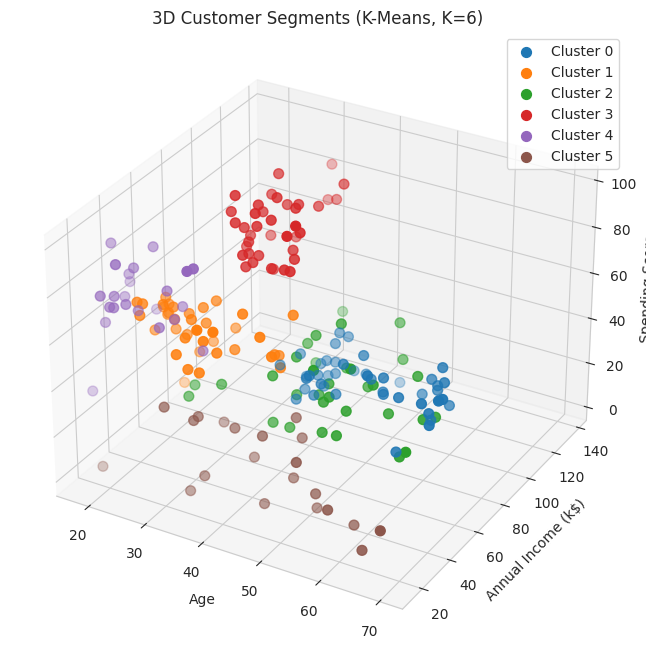

In [18]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

palette_3d = sns.color_palette("tab10", K_3D)
for cluster_id in range(K_3D):
    cluster_points = data[data["cluster_3d"] == cluster_id]
    ax.scatter(
        cluster_points["age"], cluster_points["annual_income_k"], cluster_points["spending_score"],
        s=50, color=palette_3d[cluster_id], label=f"Cluster {cluster_id}"
    )

ax.set_xlabel("Age")
ax.set_ylabel("Annual Income (k$)")
ax.set_zlabel("Spending Score")
ax.set_title(f"3D Customer Segments (K-Means, K={K_3D})")
ax.legend()
plt.show()


In [19]:
segment_summary_3d = data.groupby("cluster_3d").agg(
    count=("customer_id", "count"),
    avg_age=("age", "mean"),
    avg_income_k=("annual_income_k", "mean"),
    avg_spending_score=("spending_score", "mean"),
).round(1)

segment_summary_3d


,count,avg_age,avg_income_k,avg_spending_score
cluster_3d,,,,
0,45,56.3,54.3,49.1
1,39,26.8,57.1,48.1
2,33,41.9,88.9,17.0
3,39,32.7,86.5,82.1
4,23,25.0,25.3,77.6
5,21,45.5,26.3,19.4


## 9. Conclusion

- The Mall Customers dataset was pre-processed (missing-value check, gender encoding, feature scaling) and segmented with **K-Means clustering**.
- The **Elbow Method** and **Silhouette Score** were used together to justify the number of clusters, landing on **K = 5** for the primary income-vs-spending segmentation — a well-known, cleanly separable structure for this dataset.
- The five resulting segments map naturally to common marketing personas: e.g. **high income & high spending** ("target" customers worth premium offers), **high income & low spending** ("careful" spenders who may need more persuasion), and **low income & high spending** ("impulsive" younger shoppers).
- A bonus **3D clustering** (age, income, spending score) shows how adding a third behavioural dimension can further refine these personas — useful when income and spending alone aren't enough to fully separate customer types.
- These segments could directly inform targeted marketing campaigns, loyalty program design, or personalized promotions.

**Possible next steps:** try additional clustering algorithms (DBSCAN, Hierarchical Clustering) for comparison, incorporate more behavioural features (purchase frequency, recency, product categories) if available, and validate segment stability across different random seeds.
